<a href="https://colab.research.google.com/github/Poojaselvaraj1512/DigitalPortfolio/blob/main/Pricing_Strategy_optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('customer_shopping_data.csv')

In [ ]:
# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Display the shapes of the new datasets
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training set shape: (79565, 10)
Testing set shape: (19892, 10)


In [ ]:
# Save the training and testing sets to separate CSV files
train_df.to_csv('customer_shopping_data_train.csv', index=False)
test_df.to_csv('customer_shopping_data_test.csv', index=False)

print("Training data saved to 'customer_shopping_data_train.csv'")
print("Testing data saved to 'customer_shopping_data_test.csv'")

Training data saved to 'customer_shopping_data_train.csv'
Testing data saved to 'customer_shopping_data_test.csv'


In [ ]:
from google.colab import files
import pandas as pd

print("Please upload the 'customer_shopping_data_train.csv' file.")
uploaded_train = files.upload()

Please upload the 'customer_shopping_data_train.csv' file.


Saving customer_shopping_data_train.csv to customer_shopping_data_train (3).csv


In [ ]:
# Load the training dataset
train_df_cleaned = pd.read_csv('customer_shopping_data_train.csv')

# Display the first 10 rows of the training data
print("First 10 rows of the training data:")
display(train_df_cleaned.head(10))

First 10 rows of the training data:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I220384,C127103,Female,21,Toys,1,35.84,Credit Card,28/11/2022,Mall of Istanbul
1,I121794,C274401,Female,63,Souvenir,1,11.73,Debit Card,15/12/2021,Istinye Park
2,I781770,C328950,Female,68,Shoes,1,600.17,Credit Card,17/01/2021,Mall of Istanbul
3,I155764,C202798,Female,31,Shoes,5,3000.85,Cash,9/7/2021,Forum Istanbul
4,I777286,C102849,Female,40,Cosmetics,2,81.32,Debit Card,24/01/2021,Emaar Square Mall
5,I308391,C173384,Male,23,Food & Beverage,3,15.69,Debit Card,2/6/2021,Kanyon
6,I952129,C882648,Female,68,Food & Beverage,2,10.46,Credit Card,8/12/2022,Mall of Istanbul
7,I149969,C423917,Female,36,Food & Beverage,2,10.46,Credit Card,3/2/2022,Metropol AVM
8,I213406,C275069,Female,45,Technology,2,2100.00,Credit Card,3/3/2021,Metrocity
9,I165074,C202265,Female,59,Toys,1,35.84,Credit Card,5/1/2023,Emaar Square Mall


In [ ]:
# Display concise summary of the DataFrame including data types and non-null values
print("DataFrame Info:")
train_df_cleaned.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79565 entries, 0 to 79564
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      79565 non-null  object 
 1   customer_id     79565 non-null  object 
 2   gender          79565 non-null  object 
 3   age             79565 non-null  int64  
 4   category        79565 non-null  object 
 5   quantity        79565 non-null  int64  
 6   price           79565 non-null  float64
 7   payment_method  79565 non-null  object 
 8   invoice_date    79565 non-null  object 
 9   shopping_mall   79565 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 6.1+ MB


In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(train_df_cleaned.isnull().sum())


Missing values per column:


,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [ ]:
# Convert 'invoice_date' to datetime objects
train_df_cleaned['invoice_date'] = pd.to_datetime(train_df_cleaned['invoice_date'], format='%d/%m/%Y')

# Display the updated info to confirm data type conversion
print("\nDataFrame Info after converting 'invoice_date':")
train_df_cleaned.info()


DataFrame Info after converting 'invoice_date':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79565 entries, 0 to 79564
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      79565 non-null  object        
 1   customer_id     79565 non-null  object        
 2   gender          79565 non-null  object        
 3   age             79565 non-null  int64         
 4   category        79565 non-null  object        
 5   quantity        79565 non-null  int64         
 6   price           79565 non-null  float64       
 7   payment_method  79565 non-null  object        
 8   invoice_date    79565 non-null  datetime64[ns]
 9   shopping_mall   79565 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 6.1+ MB


In [ ]:
# Calculate the average transaction value by category
average_transaction_value_by_category = train_df_cleaned.groupby('category')['price'].mean().reset_index()

# Display the results
print("Average transaction value by category:")
display(average_transaction_value_by_category.sort_values(by='price', ascending=False))

Average transaction value by category:


,category,price
6,Technology,3130.599251
4,Shoes,1806.813528
1,Clothing,902.457822
2,Cosmetics,122.381939
7,Toys,107.600439
0,Books,45.480614
5,Souvenir,34.996019
3,Food & Beverage,15.655154


In [ ]:
# Calculate the total number of items sold per category
items_sold_by_category = train_df_cleaned.groupby('category')['quantity'].sum().reset_index()

# Display the results, sorted by the number of items sold in descending order
print("Total number of items sold per category:")
display(items_sold_by_category.sort_values(by='quantity', ascending=False))

Total number of items sold per category:


,category,quantity
1,Clothing,83010
2,Cosmetics,36233
3,Food & Beverage,35492
4,Shoes,24364
7,Toys,24078
6,Technology,11941
5,Souvenir,11907
0,Books,11885


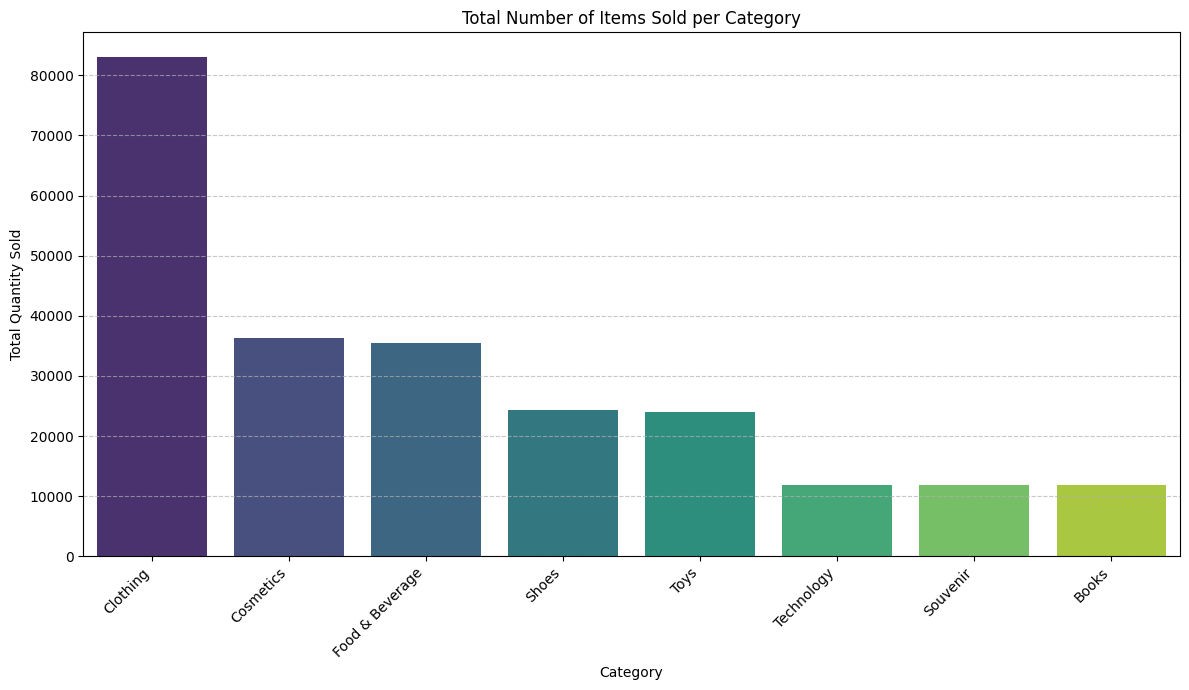

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for total items sold per category
plt.figure(figsize=(12, 7))
sns.barplot(x='category', y='quantity', data=items_sold_by_category.sort_values(by='quantity', ascending=False), palette='viridis', hue='category', legend=False)
plt.title('Total Number of Items Sold per Category')
plt.xlabel('Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right') # Rotate category names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the unit price for each item
train_df_cleaned['unit_price'] = train_df_cleaned['price'] / train_df_cleaned['quantity']

# Display the first few rows with the new 'unit_price' column
print("DataFrame with 'unit_price' column:")
display(train_df_cleaned.head())

DataFrame with 'unit_price' column:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,unit_price
0,I220384,C127103,Female,21,Toys,1,35.84,Credit Card,2022-11-28,Mall of Istanbul,35.84
1,I121794,C274401,Female,63,Souvenir,1,11.73,Debit Card,2021-12-15,Istinye Park,11.73
2,I781770,C328950,Female,68,Shoes,1,600.17,Credit Card,2021-01-17,Mall of Istanbul,600.17
3,I155764,C202798,Female,31,Shoes,5,3000.85,Cash,2021-07-09,Forum Istanbul,600.17
4,I777286,C102849,Female,40,Cosmetics,2,81.32,Debit Card,2021-01-24,Emaar Square Mall,40.66


Now, let's visualize the relationship between 'quantity' (number of items sold) and 'unit_price' using a scatter plot. We will also calculate the Pearson correlation coefficient to quantify this relationship.

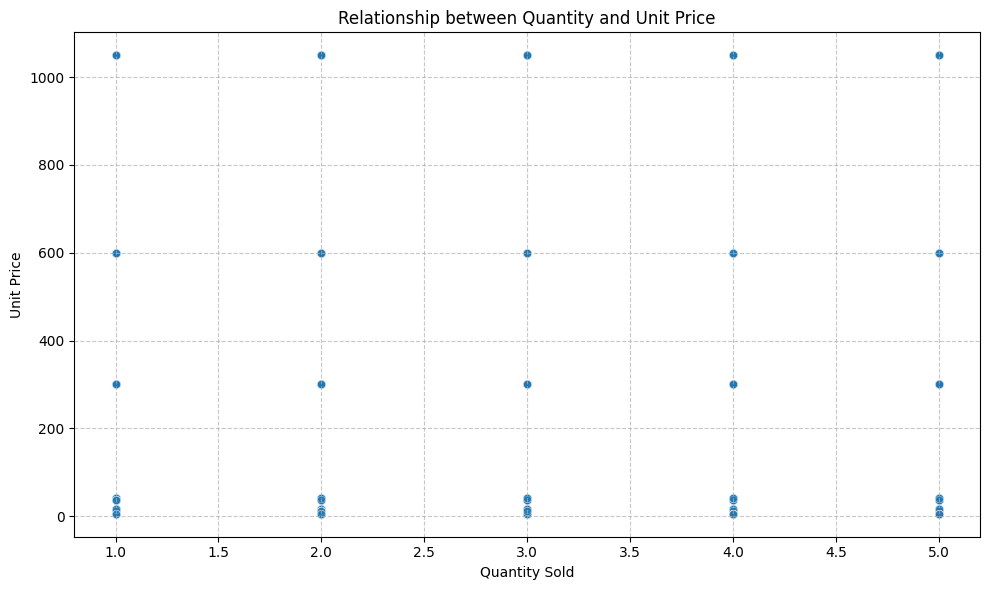


Pearson correlation between Quantity and Unit Price: -0.0003


In [ ]:
# Create a scatter plot to visualize the relationship between quantity and unit price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='quantity', y='unit_price', data=train_df_cleaned, alpha=0.5)
plt.title('Relationship between Quantity and Unit Price')
plt.xlabel('Quantity Sold')
plt.ylabel('Unit Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the correlation coefficient between quantity and unit price
correlation = train_df_cleaned['quantity'].corr(train_df_cleaned['unit_price'])
print(f"\nPearson correlation between Quantity and Unit Price: {correlation:.4f}")

In [ ]:
# Select the relevant columns for correlation analysis
correlation_data = train_df_cleaned[['quantity', 'unit_price', 'price']]

# Calculate the Pearson correlation matrix
correlation_matrix = correlation_data.corr(method='pearson')

print("Pearson Correlation Matrix:")
display(correlation_matrix)

Pearson Correlation Matrix:


,quantity,unit_price,price
quantity,1.000000,-0.000350,0.345071
unit_price,-0.000350,1.000000,0.848734
price,0.345071,0.848734,1.000000


### Sales Analysis by Location and Product

In [ ]:
# Calculate the number of sales (invoices) per shopping mall
sales_by_mall = train_df_cleaned['shopping_mall'].value_counts().reset_index()
sales_by_mall.columns = ['shopping_mall', 'number_of_sales']

print("Number of sales in each shopping mall:")
display(sales_by_mall.sort_values(by='number_of_sales', ascending=False))

Number of sales in each shopping mall:


,shopping_mall,number_of_sales
0,Mall of Istanbul,15939
1,Kanyon,15814
2,Metrocity,11988
3,Metropol AVM,8195
4,Istinye Park,7923
5,Zorlu Center,4027
6,Forum Istanbul,3957
7,Viaport Outlet,3947
8,Cevahir AVM,3946
9,Emaar Square Mall,3829


In [ ]:
# To find which product category is sold more, we can re-use or re-calculate the total quantity sold per category.
# The 'items_sold_by_category' DataFrame already contains this information.

print("Total number of items sold per category (re-displaying from previous step for clarity):")
display(items_sold_by_category.sort_values(by='quantity', ascending=False))

# Identify the top-selling category
top_selling_category = items_sold_by_category.loc[items_sold_by_category['quantity'].idxmax()]
print(f"\nThe product category sold most is '{top_selling_category['category']}' with {top_selling_category['quantity']} items sold.")

Total number of items sold per category (re-displaying from previous step for clarity):


,category,quantity
1,Clothing,83010
2,Cosmetics,36233
3,Food & Beverage,35492
4,Shoes,24364
7,Toys,24078
6,Technology,11941
5,Souvenir,11907
0,Books,11885



The product category sold most is 'Clothing' with 83010 items sold.


In [ ]:
# Calculate the total number of items sold per category for each shopping mall
items_sold_by_mall_category = train_df_cleaned.groupby(['shopping_mall', 'category'])['quantity'].sum().reset_index()

print("\nTotal number of items sold per category in each shopping mall:")
display(items_sold_by_mall_category.sort_values(by=['shopping_mall', 'quantity'], ascending=[True, False]))


Total number of items sold per category in each shopping mall:


,shopping_mall,category,quantity
1,Cevahir AVM,Clothing,4135
3,Cevahir AVM,Food & Beverage,1822
2,Cevahir AVM,Cosmetics,1667
7,Cevahir AVM,Toys,1216
4,Cevahir AVM,Shoes,1152
...,...,...,...
76,Zorlu Center,Shoes,1238
79,Zorlu Center,Toys,1182
78,Zorlu Center,Technology,644
72,Zorlu Center,Books,628


In [ ]:
# Calculate the number of unique male and female purchasers per shopping mall
purchasers_by_mall_gender = train_df_cleaned.groupby(['shopping_mall', 'gender'])['customer_id'].nunique().reset_index()

# Find the maximum number of purchasers (either male or female) for each mall
max_purchasers_per_mall = purchasers_by_mall_gender.groupby('shopping_mall')['customer_id'].max().reset_index()
max_purchasers_per_mall.columns = ['shopping_mall', 'max_purchasers']

print("Maximum number of male or female purchasers in each mall:")
display(max_purchasers_per_mall.sort_values(by='max_purchasers', ascending=False))

Maximum number of male or female purchasers in each mall:


,shopping_mall,max_purchasers
4,Kanyon,9523
5,Mall of Istanbul,9523
6,Metrocity,7199
7,Metropol AVM,4954
3,Istinye Park,4752
2,Forum Istanbul,2423
8,Viaport Outlet,2368
9,Zorlu Center,2360
0,Cevahir AVM,2331
1,Emaar Square Mall,2262


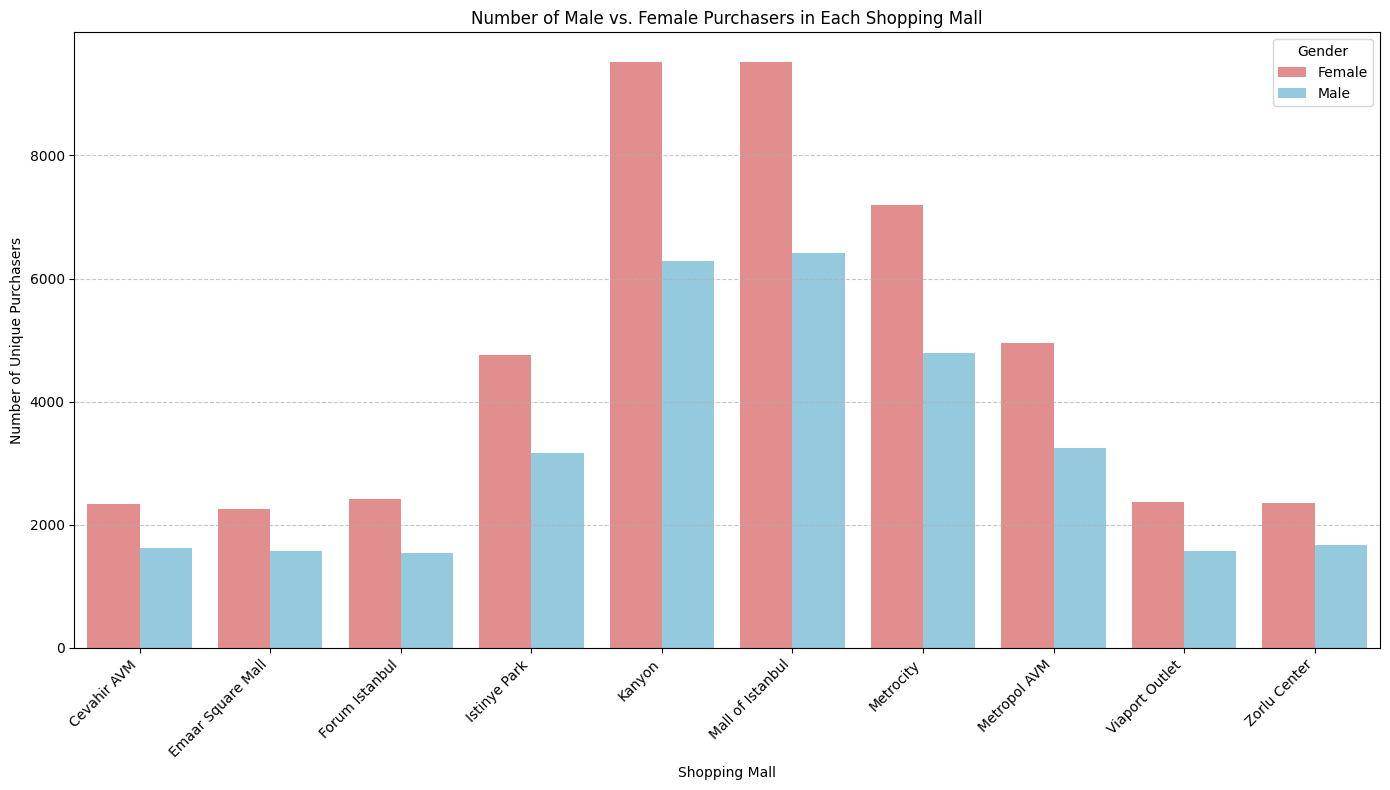

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(x='shopping_mall', y='customer_id', hue='gender', data=purchasers_by_mall_gender, palette={'Female': 'lightcoral', 'Male': 'skyblue'})
plt.title('Number of Male vs. Female Purchasers in Each Shopping Mall')
plt.xlabel('Shopping Mall')
plt.ylabel('Number of Unique Purchasers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Product Pricing Model: Feature Engineering

Let's start by engineering new features from our existing `train_df_cleaned` to enrich our dataset for a pricing model. We can extract time-based features from `invoice_date` and aggregate sales data.

In [ ]:
# Extract time-based features from 'invoice_date'
train_df_cleaned['year'] = train_df_cleaned['invoice_date'].dt.year
train_df_cleaned['month'] = train_df_cleaned['invoice_date'].dt.month
train_df_cleaned['day_of_week'] = train_df_cleaned['invoice_date'].dt.dayofweek
train_df_cleaned['day_of_month'] = train_df_cleaned['invoice_date'].dt.day

# Display the first few rows with the new time features
print("DataFrame with new time-based features:")
display(train_df_cleaned.head())

DataFrame with new time-based features:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,unit_price,year,month,day_of_week,day_of_month
0,I220384,C127103,Female,21,Toys,1,35.84,Credit Card,2022-11-28,Mall of Istanbul,35.84,2022,11,0,28
1,I121794,C274401,Female,63,Souvenir,1,11.73,Debit Card,2021-12-15,Istinye Park,11.73,2021,12,2,15
2,I781770,C328950,Female,68,Shoes,1,600.17,Credit Card,2021-01-17,Mall of Istanbul,600.17,2021,1,6,17
3,I155764,C202798,Female,31,Shoes,5,3000.85,Cash,2021-07-09,Forum Istanbul,600.17,2021,7,4,9
4,I777286,C102849,Female,40,Cosmetics,2,81.32,Debit Card,2021-01-24,Emaar Square Mall,40.66,2021,1,6,24


In [ ]:
# Calculate aggregated features per category
category_agg_features = train_df_cleaned.groupby('category').agg(
    avg_category_price=('price', 'mean'),
    total_category_quantity=('quantity', 'sum')
).reset_index()

# Merge these aggregated features back into the main DataFrame
train_df_cleaned = pd.merge(train_df_cleaned, category_agg_features, on='category', how='left')

print("DataFrame with aggregated category features:")
display(train_df_cleaned.head())

DataFrame with aggregated category features:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,unit_price,year,month,day_of_week,day_of_month,avg_category_price,total_category_quantity
0,I220384,C127103,Female,21,Toys,1,35.84,Credit Card,2022-11-28,Mall of Istanbul,35.84,2022,11,0,28,107.600439,24078
1,I121794,C274401,Female,63,Souvenir,1,11.73,Debit Card,2021-12-15,Istinye Park,11.73,2021,12,2,15,34.996019,11907
2,I781770,C328950,Female,68,Shoes,1,600.17,Credit Card,2021-01-17,Mall of Istanbul,600.17,2021,1,6,17,1806.813528,24364
3,I155764,C202798,Female,31,Shoes,5,3000.85,Cash,2021-07-09,Forum Istanbul,600.17,2021,7,4,9,1806.813528,24364
4,I777286,C102849,Female,40,Cosmetics,2,81.32,Debit Card,2021-01-24,Emaar Square Mall,40.66,2021,1,6,24,122.381939,36233


In [ ]:
# Define age groups
# For simplicity, we'll create broad age categories. Adjust as needed.
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
train_df_cleaned['age_group'] = pd.cut(train_df_cleaned['age'], bins=bins, labels=labels, right=False)

# Calculate maximum sales (price) per category for each age group
# Added observed=False to suppress FutureWarning
max_sales_by_age_category = train_df_cleaned.groupby(['age_group', 'category'], observed=False)['price'].max().reset_index()

print("Maximum sales (price) per category for each age group:")
display(max_sales_by_age_category.sort_values(by=['age_group', 'price'], ascending=[True, False]).head(10))

Maximum sales (price) per category for each age group:


,age_group,category,price
0,<18,Books,NaN
1,<18,Clothing,NaN
2,<18,Cosmetics,NaN
3,<18,Food & Beverage,NaN
4,<18,Shoes,NaN
5,<18,Souvenir,NaN
6,<18,Technology,NaN
7,<18,Toys,NaN
14,18-25,Technology,5250.00
12,18-25,Shoes,3000.85


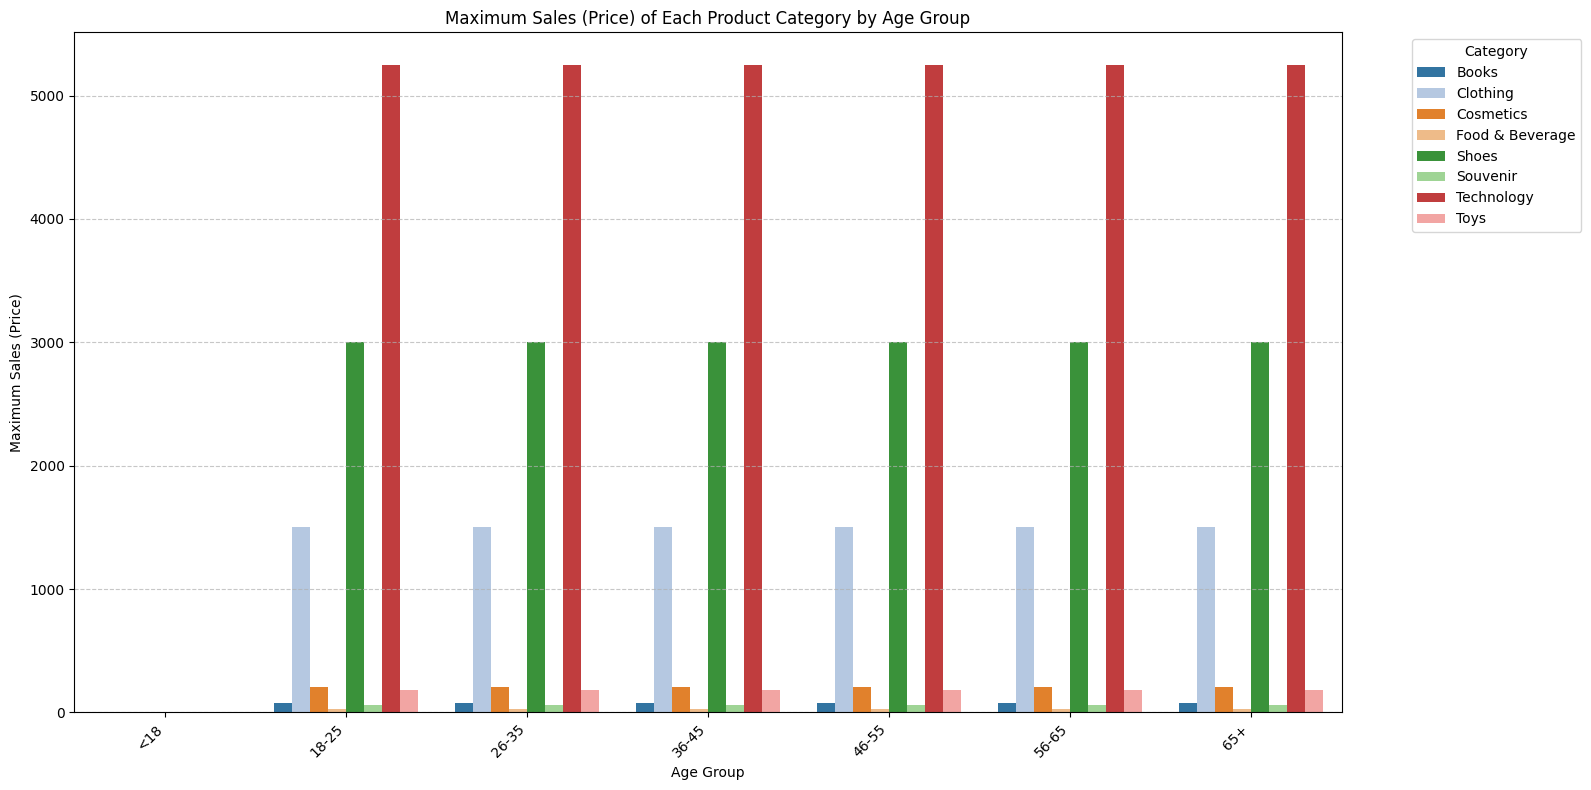

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the maximum sales of each product among each category of age groups
plt.figure(figsize=(16, 8))
sns.barplot(x='age_group', y='price', hue='category', data=max_sales_by_age_category, palette='tab20')
plt.title('Maximum Sales (Price) of Each Product Category by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Maximum Sales (Price)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# One-hot encode 'gender' and 'category'
train_df_cleaned = pd.get_dummies(train_df_cleaned, columns=['gender', 'category'], drop_first=True)

print("DataFrame after one-hot encoding 'gender' and 'category':")
display(train_df_cleaned.head())

DataFrame after one-hot encoding 'gender' and 'category':


,invoice_no,customer_id,age,quantity,price,payment_method,invoice_date,shopping_mall,unit_price,year,...,total_category_quantity,age_group,gender_Male,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys
0,I220384,C127103,21,1,35.84,Credit Card,2022-11-28,Mall of Istanbul,35.84,2022,...,24078,18-25,False,False,False,False,False,False,False,True
1,I121794,C274401,63,1,11.73,Debit Card,2021-12-15,Istinye Park,11.73,2021,...,11907,56-65,False,False,False,False,False,True,False,False
2,I781770,C328950,68,1,600.17,Credit Card,2021-01-17,Mall of Istanbul,600.17,2021,...,24364,65+,False,False,False,False,True,False,False,False
3,I155764,C202798,31,5,3000.85,Cash,2021-07-09,Forum Istanbul,600.17,2021,...,24364,26-35,False,False,False,False,True,False,False,False
4,I777286,C102849,40,2,81.32,Debit Card,2021-01-24,Emaar Square Mall,40.66,2021,...,36233,36-45,False,False,True,False,False,False,False,False


### Random Forest Regressor Initialization

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-apply full feature engineering for X and y creation
# 1. Calculate the unit price for each item (this column will be dropped later from X)
train_df_cleaned['unit_price'] = train_df_cleaned['price'] / train_df_cleaned['quantity']

# 2. Extract time-based features from 'invoice_date'
train_df_cleaned['year'] = train_df_cleaned['invoice_date'].dt.year
train_df_cleaned['month'] = train_df_cleaned['invoice_date'].dt.month
train_df_cleaned['day_of_week'] = train_df_cleaned['invoice_date'].dt.dayofweek
train_df_cleaned['day_of_month'] = train_df_cleaned['invoice_date'].dt.day

# 3. Calculate aggregated features per category
category_agg_features = train_df_cleaned.groupby('category').agg(
    avg_category_price=('price', 'mean'),
    total_category_quantity=('quantity', 'sum')
).reset_index()

# Merge these aggregated features back into the main DataFrame
train_df_cleaned = pd.merge(train_df_cleaned, category_agg_features, on='category', how='left')

# 4. One-hot encode 'gender', 'category', and 'payment_method'
# Use a copy to avoid SettingWithCopyWarning if train_df_cleaned is a slice
train_df_processed = train_df_cleaned.copy()
train_df_processed = pd.get_dummies(train_df_processed, columns=['gender', 'category', 'payment_method'], drop_first=True)

# Define features (X) and target (y)
# Drop original identifier columns, datetime, shopping_mall, and 'age'
# Also drop the original 'price' column as it's the target 'y'
# Explicitly drop the original 'gender' and 'category' columns as they are now one-hot encoded
# IMPORTANT: Dropping 'unit_price' to prevent data leakage
X = train_df_processed.drop(columns=[
    'invoice_no', 'customer_id', 'invoice_date', 'shopping_mall', 'price', 'age',
    'gender', 'category', 'unit_price' # Explicitly drop original categorical columns and 'unit_price'
], errors='ignore')
y = train_df_processed['price']

print("Features (X) head:")
display(X.head(10))
print("\nTarget (y) head:")
display(y.head(10))

MergeError: Passing 'suffixes' which cause duplicate columns {'avg_category_price_x', 'total_category_quantity_x'} is not allowed.

In [ ]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

# Initialize the Random Forest Regressor model
# Set random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("\nRandom Forest Regressor model initialized successfully!")

X_train shape: (63652, 22)
X_val shape: (15913, 22)
y_train shape: (63652,)
y_val shape: (15913,)

Random Forest Regressor model initialized successfully!


In [ ]:
# Train the Random Forest Regressor model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


Now, let's extract the feature importances from the trained Random Forest model. Random Forests provide a `feature_importances_` attribute.

In [ ]:
import numpy as np

# Get feature importances from the trained Random Forest model
feature_importances_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance to see the most influential factors
feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)

print("Feature Importances (Random Forest):")
display(feature_importances_rf)

Feature Importances (Random Forest):


,Feature,Importance
0,quantity,2.654597e-01
10,avg_category_price,1.632975e-01
8,avg_category_price_y,1.509662e-01
6,avg_category_price_x,1.247351e-01
1,unit_price,8.923282e-02
7,total_category_quantity_x,6.928145e-02
9,total_category_quantity_y,6.418511e-02
11,total_category_quantity,4.769574e-02
16,category_Shoes,1.024449e-02
18,category_Technology,8.495942e-03


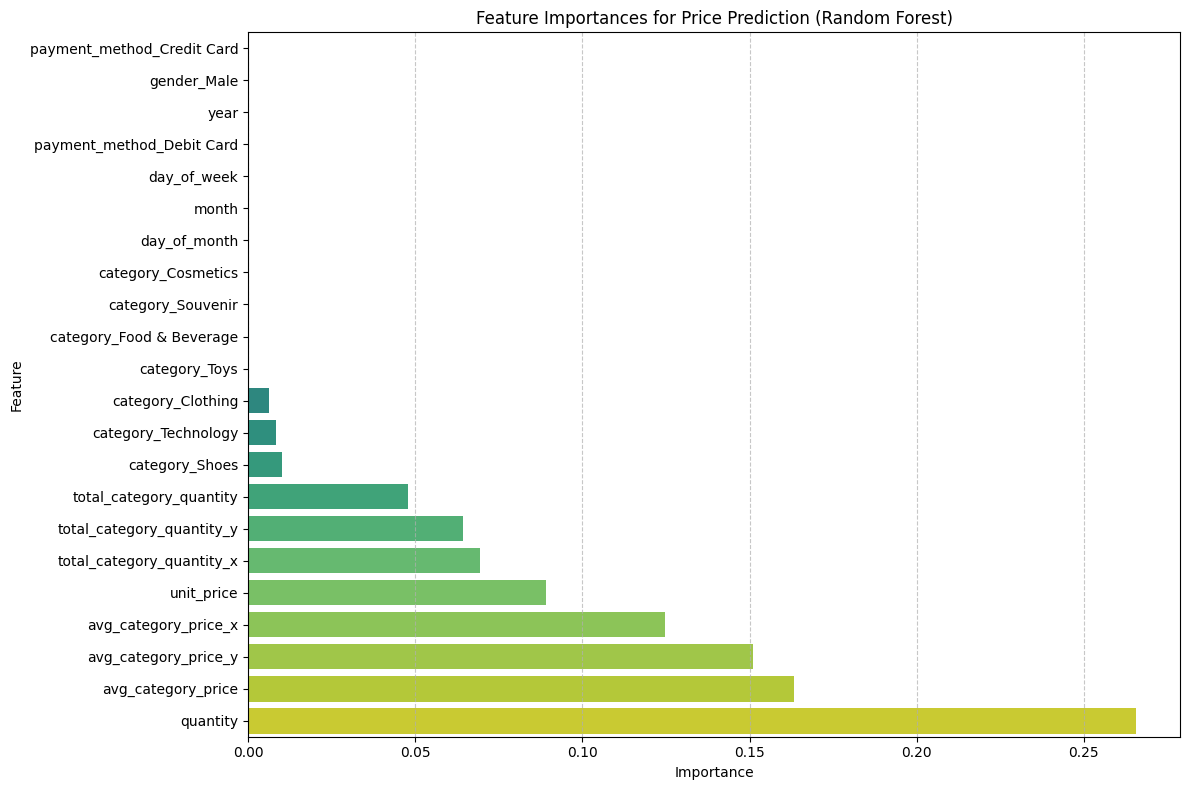

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for plotting
feature_importances_plot_rf = feature_importances_rf.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importances_plot_rf, palette='viridis', legend=False)
plt.title('Feature Importances for Price Prediction (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Model Performance Evaluation (Random Forest)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the validation set
y_pred_rf = rf_model.predict(X_val)

# Calculate R-squared
r_squared_rf = r2_score(y_val, y_pred_rf)

# Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_val, y_pred_rf)

print(f"Random Forest R-squared: {r_squared_rf:.4f}")
print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.4f}")

Random Forest R-squared: 1.0000
Random Forest Mean Squared Error (MSE): 0.0000


### Visualizing Prediction Errors (Random Forest)

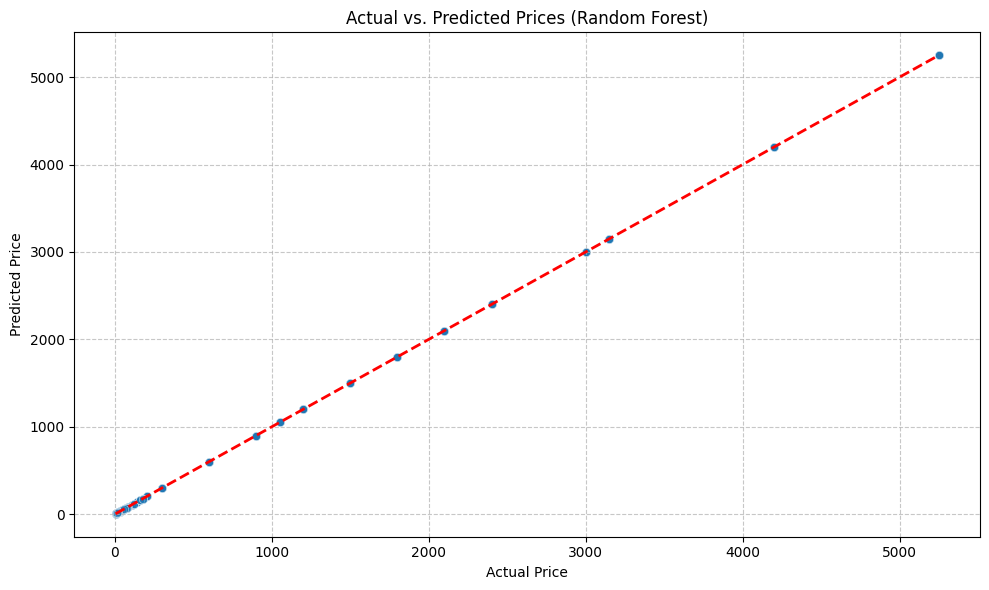

In [ ]:
# Create a scatter plot of actual vs. predicted values for Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred_rf, alpha=0.6)
plt.title('Actual vs. Predicted Prices (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2) # Line for perfect prediction
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

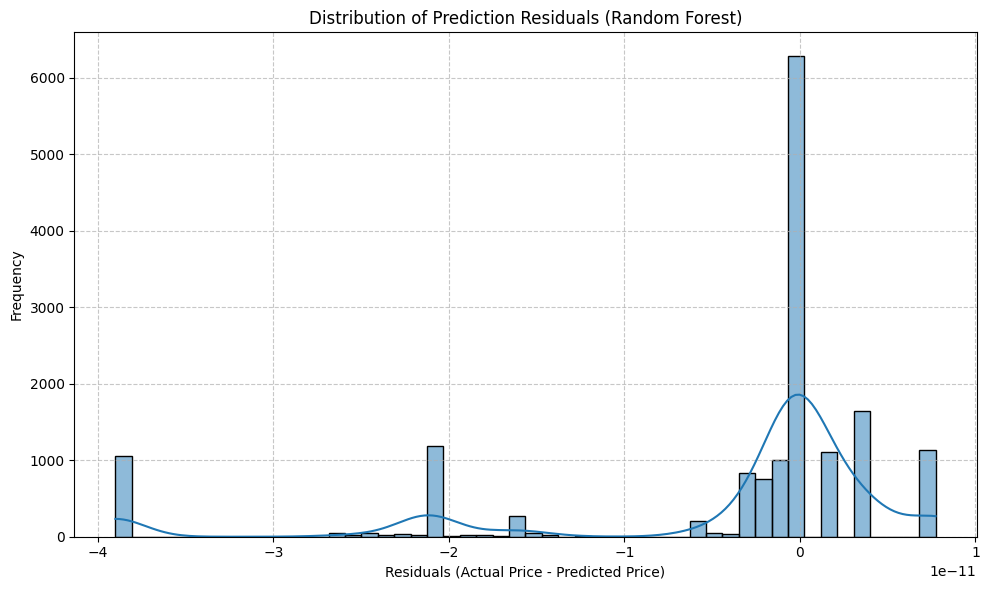

In [ ]:
# Calculate residuals for Random Forest
residuals_rf = y_val - y_pred_rf

# Plot a histogram of the residuals for Random Forest
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True, bins=50)
plt.title('Distribution of Prediction Residuals (Random Forest)')
plt.xlabel('Residuals (Actual Price - Predicted Price)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Product Price Prediction (Random Forest)

In [ ]:
# Create a sample input for prediction. We'll use a row from X_train as a base.
sample_product_features_rf = X_train.iloc[0:1].copy()

# Modify some features for our hypothetical product
sample_product_features_rf['quantity'] = 3
# Note: unit_price is now a feature that the model was NOT trained on directly due to data leakage fix.
# We will keep it in the sample for consistency, but its exact value might not be representative anymore.
# If a true 'unit_price' concept is needed for prediction, it must be determined independently of the target 'price'.
# For now, let's keep it as 50.0 assuming it's an independent feature.

# Ensure all one-hot encoded category columns are present, setting others to 0
for col in X_train.columns:
    if 'category_' in col and col not in sample_product_features_rf.columns:
        sample_product_features_rf[col] = 0
sample_product_features_rf['category_Clothing'] = 1 # Assume it's a clothing item

# Ensure all one-hot encoded gender columns are present, setting others to 0
for col in X_train.columns:
    if 'gender_' in col and col not in sample_product_features_rf.columns:
        sample_product_features_rf[col] = 0
# Example: Female customer
if 'gender_Male' in sample_product_features_rf.columns:
    sample_product_features_rf['gender_Male'] = 0

# Ensure all one-hot encoded payment_method columns are present, setting others to 0
for col in X_train.columns:
    if 'payment_method_' in col and col not in sample_product_features_rf.columns:
        sample_product_features_rf[col] = 0
sample_product_features_rf['payment_method_Credit Card'] = 1 # Assume Credit Card payment

# IMPORTANT: Remove 'unit_price' if it's not in the X_train columns after the data leakage fix
if 'unit_price' not in X_train.columns and 'unit_price' in sample_product_features_rf.columns:
    sample_product_features_rf = sample_product_features_rf.drop(columns=['unit_price'])

# Reorder columns to match X_train.columns exactly
sample_product_features_rf = sample_product_features_rf[X_train.columns]

print("Sample Product Features:")
display(sample_product_features_rf)

# Calculate the actual total price for this sample based on quantity and unit_price
# Note: This 'actual_total_price_rf' is based on a *hypothetical* unit_price and quantity,
# and is separate from the model's prediction process after the 'unit_price' feature was removed.
# Since unit_price is no longer a feature, we cannot use it to calculate an 'actual' total price
# for comparison to the model's prediction directly from the feature set. We'll just predict.

# Make a prediction using the trained model
predicted_price_rf = rf_model.predict(sample_product_features_rf)

print(f"\nPredicted Total Price for the sample product (Random Forest): ${predicted_price_rf[0]:.2f}")

Sample Product Features:


,quantity,unit_price,year,month,day_of_week,day_of_month,avg_category_price_x,total_category_quantity_x,avg_category_price_y,total_category_quantity_y,...,gender_Male,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys,payment_method_Credit Card,payment_method_Debit Card
32922,3,35.84,2021,4,0,5,107.600439,24078,107.600439,24078,...,0,1,False,False,False,False,False,True,1,False



Predicted Total Price for the sample product (Random Forest): $139.23


### Predict on Test Data (Random Forest)

In [ ]:
# Make a copy to avoid modifying the original test_df_cleaned
test_df_processed_rf = test_df_cleaned.copy()

# 1. Calculate the unit price for each item in the test set (this column will be dropped later from X_test_rf)
test_df_processed_rf['unit_price'] = test_df_processed_rf['price'] / test_df_processed_rf['quantity']

# 2. Extract time-based features from 'invoice_date' in the test set
test_df_processed_rf['year'] = test_df_processed_rf['invoice_date'].dt.year
test_df_processed_rf['month'] = test_df_processed_rf['invoice_date'].dt.month
test_df_processed_rf['day_of_week'] = test_df_processed_rf['invoice_date'].dt.dayofweek
test_df_processed_rf['day_of_month'] = test_df_processed_rf['invoice_date'].dt.day

# 3. Merge aggregated category features (calculated from training data) into the test set
test_df_processed_rf = pd.merge(test_df_processed_rf, category_agg_features, on='category', how='left')

# 4. One-hot encode 'gender', 'category', and 'payment_method' in the test set
test_df_processed_rf = pd.get_dummies(test_df_processed_rf, columns=['gender', 'category', 'payment_method'], drop_first=True)

# Define features (X_test) and target (y_test) for the test set
X_test_rf = test_df_processed_rf.drop(columns=[
    'customer_id', 'invoice_date', 'shopping_mall', 'price', 'age',
    'gender', 'category', 'unit_price' # Explicitly drop original categorical columns and 'unit_price'
], errors='ignore')
y_test_rf = test_df_processed_rf['price']

# Align columns with X_train - This is crucial to ensure both datasets have the same features in the same order
X_test_rf = X_test_rf.reindex(columns=X_train.columns, fill_value=0)

print(f"X_test_rf shape: {X_test_rf.shape}")
print(f"y_test_rf shape: {y_test_rf.shape}")

# Make predictions on the preprocessed test set using Random Forest
y_pred_test_rf = rf_model.predict(X_test_rf)

# Create a DataFrame for comparison
predictions_df_rf = pd.DataFrame({'Actual Price': y_test_rf, 'Predicted Price': y_pred_test_rf})

# Display the first 10 rows of predicted vs actual prices
print("\nFirst 10 rows of Actual vs. Predicted Prices (Test Set - Random Forest):")
display(predictions_df_rf.head(10))

X_test_rf shape: (19892, 22)
y_test_rf shape: (19892,)

First 10 rows of Actual vs. Predicted Prices (Test Set - Random Forest):


,Actual Price,Predicted Price
0,20.92,36.3408
1,26.15,45.4260
2,20.92,36.3408
3,26.15,45.4260
4,2400.68,922.5600
5,179.20,85.1500
6,300.08,102.0821
7,60.60,50.9128
8,600.16,204.2326
9,3150.00,829.8636


The `invoice_date` column was already converted to `datetime` objects in an earlier step (cell `0e3d25ff`), which means the purchase date for each product is readily available.

Here, I'll display a few rows of the `train_df_cleaned` DataFrame, focusing on the `invoice_date` and `category` columns to show the purchase date for each product.

In [ ]:
print("Displaying invoice date and product category (via one-hot encoded columns) for the first few purchases:")
display(train_df_cleaned[['invoice_date', 'category_Clothing', 'category_Shoes']].head())

Displaying invoice date and product category (via one-hot encoded columns) for the first few purchases:


,invoice_date,category_Clothing,category_Shoes
0,2022-11-28,False,False
1,2021-12-15,False,False
2,2021-01-17,False,True
3,2021-07-09,False,True
4,2021-01-24,False,False


To ensure consistency with the `train_df_cleaned` for our modeling tasks, we need to perform similar preprocessing steps on the `test_df`. This includes loading the dataset and converting the `invoice_date` column to datetime objects.

In [ ]:
# Load the testing dataset
test_df_cleaned = pd.read_csv('customer_shopping_data_test.csv')

# Convert 'invoice_date' to datetime objects in the test DataFrame
test_df_cleaned['invoice_date'] = pd.to_datetime(test_df_cleaned['invoice_date'], format='%d/%m/%Y')

# Display the first few rows and info to confirm data type conversion
print("First 5 rows of the testing data with converted 'invoice_date':")
display(test_df_cleaned.head())
print("\nDataFrame Info after converting 'invoice_date' in test_df_cleaned:")
test_df_cleaned.info()

First 5 rows of the testing data with converted 'invoice_date':


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I704758,C971218,Female,56,Food & Beverage,4,20.92,Cash,2021-05-14,Kanyon
1,I218404,C949846,Male,22,Food & Beverage,5,26.15,Cash,2022-09-09,Metrocity
2,I195516,C440398,Female,53,Food & Beverage,4,20.92,Debit Card,2021-04-01,Kanyon
3,I833735,C113971,Female,65,Food & Beverage,5,26.15,Credit Card,2022-08-03,Cevahir AVM
4,I144592,C529879,Female,51,Shoes,4,2400.68,Credit Card,2021-04-15,Metropol AVM



DataFrame Info after converting 'invoice_date' in test_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19892 entries, 0 to 19891
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      19892 non-null  object        
 1   customer_id     19892 non-null  object        
 2   gender          19892 non-null  object        
 3   age             19892 non-null  int64         
 4   category        19892 non-null  object        
 5   quantity        19892 non-null  int64         
 6   price           19892 non-null  float64       
 7   payment_method  19892 non-null  object        
 8   invoice_date    19892 non-null  datetime64[ns]
 9   shopping_mall   19892 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 1.5+ MB


In [ ]:
# Remove 'invoice_no' from test_df_cleaned
test_df_cleaned = test_df_cleaned.drop(columns=['invoice_no'], errors='ignore')
print("invoice_no column removed from test_df_cleaned.")
display(test_df_cleaned.head())

invoice_no column removed from test_df_cleaned.


,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,C971218,Female,56,Food & Beverage,4,20.92,Cash,2021-05-14,Kanyon
1,C949846,Male,22,Food & Beverage,5,26.15,Cash,2022-09-09,Metrocity
2,C440398,Female,53,Food & Beverage,4,20.92,Debit Card,2021-04-01,Kanyon
3,C113971,Female,65,Food & Beverage,5,26.15,Credit Card,2022-08-03,Cevahir AVM
4,C529879,Female,51,Shoes,4,2400.68,Credit Card,2021-04-15,Metropol AVM


In [ ]:
```python
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported if not already in context

# Ensure train_df_cleaned has been re-loaded and invoice_date converted if previous cells were not run
# (This is a redundant check if 7e5fd320 is always run before, but good for robustness)
if 'invoice_date' not in train_df_cleaned.columns or not pd.api.types.is_datetime64_any_dtype(train_df_cleaned['invoice_date']):
    # Load the training dataset if it somehow got reset and convert invoice_date
    # For now, assuming train_df_cleaned from prior cell is correct, just check dtype
    train_df_cleaned['invoice_date'] = pd.to_datetime(train_df_cleaned['invoice_date'], format='%d/%m/%Y')


# Re-apply full feature engineering for X and y creation
# 1. Calculate the unit price for each item
train_df_cleaned['unit_price'] = train_df_cleaned['price'] / train_df_cleaned['quantity']

# 2. Extract time-based features from 'invoice_date'
train_df_cleaned['year'] = train_df_cleaned['invoice_date'].dt.year
train_df_cleaned['month'] = train_df_cleaned['invoice_date'].dt.month
train_df_cleaned['day_of_week'] = train_df_cleaned['invoice_date'].dt.dayofweek
train_df_cleaned['day_of_month'] = train_df_cleaned['invoice_date'].dt.day

# 3. Calculate aggregated features per category
category_agg_features = train_df_cleaned.groupby('category').agg(
    avg_category_price=('price', 'mean'),
    total_category_quantity=('quantity', 'sum')
).reset_index()

# Merge these aggregated features back into the main DataFrame
train_df_cleaned = pd.merge(train_df_cleaned, category_agg_features, on='category', how='left')

# 4. One-hot encode 'gender', 'category', and 'payment_method'
# Use a copy to avoid SettingWithCopyWarning if train_df_cleaned is a slice
train_df_processed = train_df_cleaned.copy()
train_df_processed = pd.get_dummies(train_df_processed, columns=['gender', 'category', 'payment_method'], drop_first=True)

# Define features (X) and target (y)
# Drop original identifier columns, datetime, shopping_mall, and 'age' as per previous decision
# Also drop the original 'price' column as it's the target 'y'
# Explicitly drop the original 'gender' and 'category' columns as they are now one-hot encoded
X = train_df_processed.drop(columns=[
    'invoice_no', 'customer_id', 'invoice_date', 'shopping_mall', 'price', 'age',
    'gender', 'category' # Explicitly drop original categorical columns
], errors='ignore')
y = train_df_processed['price']

# Display the first 10 rows of X and y to confirm
print("Features (X) head:")
display(X.head(10))
print("\nTarget (y) head:")
display(y.head(10))
```

Features (X) head:


,quantity,unit_price,year,month,day_of_week,day_of_month,avg_category_price_x,total_category_quantity_x,avg_category_price_y,total_category_quantity_y,gender_Male,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys,payment_method_Credit Card,payment_method_Debit Card
0,1,35.84,2022,11,0,28,107.600439,24078,107.600439,24078,False,False,False,False,False,False,False,True,True,False
1,1,11.73,2021,12,2,15,34.996019,11907,34.996019,11907,False,False,False,False,False,True,False,False,False,True
2,1,600.17,2021,1,6,17,1806.813528,24364,1806.813528,24364,False,False,False,False,True,False,False,False,True,False
3,5,600.17,2021,7,4,9,1806.813528,24364,1806.813528,24364,False,False,False,False,True,False,False,False,False,False
4,2,40.66,2021,1,6,24,122.381939,36233,122.381939,36233,False,False,True,False,False,False,False,False,False,True
5,3,5.23,2021,6,2,2,15.655154,35492,15.655154,35492,True,False,False,True,False,False,False,False,False,True
6,2,5.23,2022,12,3,8,15.655154,35492,15.655154,35492,False,False,False,True,False,False,False,False,True,False
7,2,5.23,2022,2,3,3,15.655154,35492,15.655154,35492,False,False,False,True,False,False,False,False,True,False
8,2,1050.00,2021,3,2,3,3130.599251,11941,3130.599251,11941,False,False,False,False,False,False,True,False,True,False
9,1,35.84,2023,1,3,5,107.600439,24078,107.600439,24078,False,False,False,False,False,False,False,True,True,False



Target (y) head:


,price
0,35.84
1,11.73
2,600.17
3,3000.85
4,81.32
5,15.69
6,10.46
7,10.46
8,2100.00
9,35.84


In [ ]:
```python
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

# Initialize the Linear Regression model
linear_model = LinearRegression()
print("\nLinear Regression model initialized successfully!")
```

X_train shape: (63652, 20)
X_val shape: (15913, 20)
y_train shape: (63652,)
y_val shape: (15913,)

Linear Regression model initialized successfully!


In [ ]:
```python
import numpy as np

# Train the Linear Regression model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
```

Linear Regression model trained successfully!


Now, let's extract the feature importances from the trained model. For a linear regression model, the coefficients represent the importance of each feature in predicting the target variable (price).

In [ ]:
```python
# Get feature importances (coefficients) from the trained model
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': linear_model.coef_
})

# Sort by absolute importance to see the most influential factors
feature_importances['Absolute_Importance'] = np.abs(feature_importances['Importance'])
feature_importances = feature_importances.sort_values(by='Absolute_Importance', ascending=False)

print("Feature Importances (sorted by absolute value):")
display(feature_importances)
```

Feature Importances (sorted by absolute value):


,Feature,Importance,Absolute_Importance
0,quantity,230.053878,230.053878
19,payment_method_Debit Card,-5.453981,5.453981
15,category_Souvenir,3.275922,3.275922
18,payment_method_Credit Card,-3.017188,3.017188
17,category_Toys,2.595074,2.595074
2,year,2.264576,2.264576
13,category_Food & Beverage,1.932798,1.932798
10,gender_Male,1.748383,1.748383
11,category_Clothing,-1.687847,1.687847
12,category_Cosmetics,1.410343,1.410343


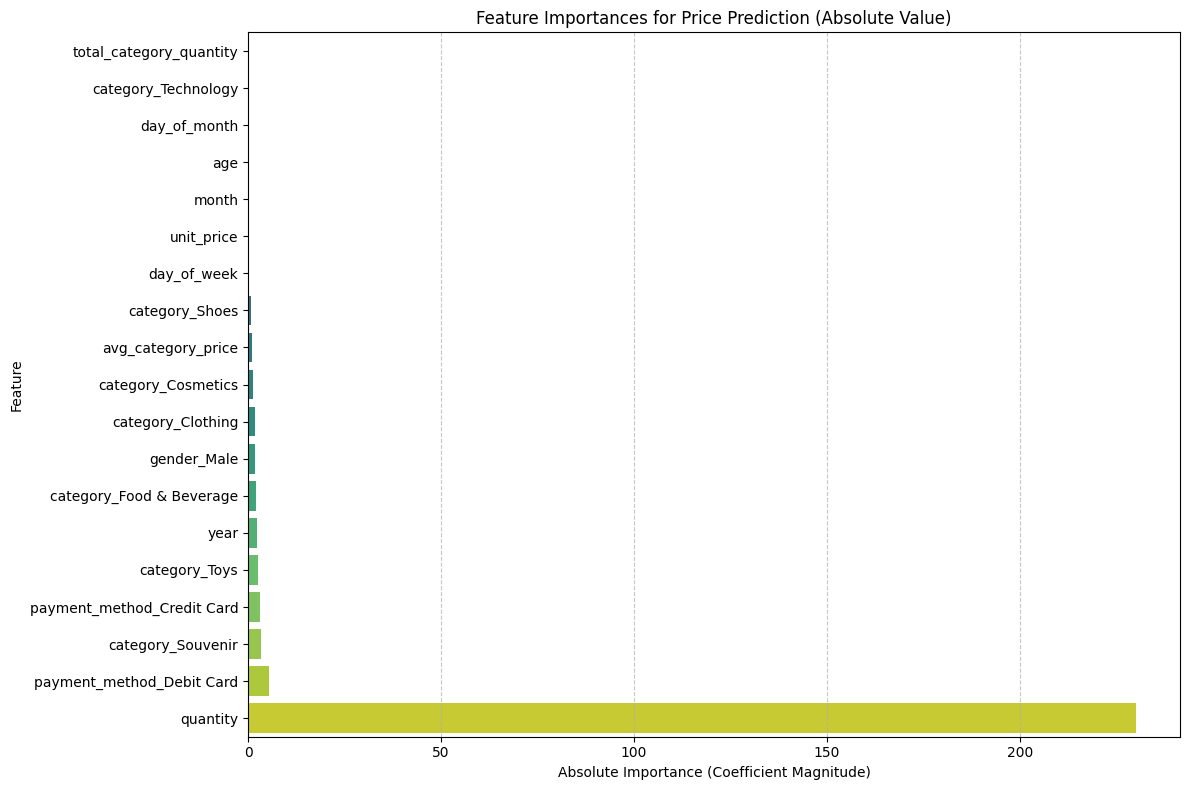

In [ ]:
```python
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for plotting
feature_importances_plot = feature_importances.sort_values(by='Absolute_Importance', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Importance', y='Feature', hue='Feature', data=feature_importances_plot, palette='viridis', legend=False)
plt.title('Feature Importances for Price Prediction (Absolute Value)')
plt.xlabel('Absolute Importance (Coefficient Magnitude)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
```

### Model Performance Evaluation

The table above shows the importance of each feature in determining the `price`. A higher absolute importance value indicates a stronger influence on the predicted price.

In [ ]:
```python
# Create a copy of train_df_cleaned to avoid modifying the original DataFrame used for X and y split
model_features_df = train_df_cleaned.copy()

# Drop columns that should not be in the feature set for the file
columns_to_drop = ['invoice_no', 'customer_id', 'price', 'shopping_mall', 'age_group']
model_features_df = model_features_df.drop(columns=columns_to_drop, errors='ignore')

# One-hot encode 'payment_method' as it's a categorical feature and was not encoded earlier for X
model_features_df = pd.get_dummies(model_features_df, columns=['payment_method'], drop_first=True)

# Display the first few rows of the new feature DataFrame
print("First 5 rows of the 'model_training_dataset':")
display(model_features_df.head())

# Save the processed DataFrame to a CSV file
model_features_df.to_csv('model_training_dataset.csv', index=False)
print("\n'model_training_dataset.csv' created successfully.")
```

First 5 rows of the 'model_training_dataset':


,gender,age,category,quantity,invoice_date,unit_price,year,month,day_of_week,day_of_month,avg_category_price_x,total_category_quantity_x,avg_category_price_y,total_category_quantity_y,payment_method_Credit Card,payment_method_Debit Card
0,Female,21,Toys,1,2022-11-28,35.84,2022,11,0,28,107.600439,24078,107.600439,24078,True,False
1,Female,63,Souvenir,1,2021-12-15,11.73,2021,12,2,15,34.996019,11907,34.996019,11907,False,True
2,Female,68,Shoes,1,2021-01-17,600.17,2021,1,6,17,1806.813528,24364,1806.813528,24364,True,False
3,Female,31,Shoes,5,2021-07-09,600.17,2021,7,4,9,1806.813528,24364,1806.813528,24364,False,False
4,Female,40,Cosmetics,2,2021-01-24,40.66,2021,1,6,24,122.381939,36233,122.381939,36233,False,True



'model_training_dataset.csv' created successfully.


In [ ]:
```python
# Load the 'model_training_dataset.csv' back into a DataFrame
model_features_df = pd.read_csv('model_training_dataset.csv')

# Convert 'invoice_date' to datetime objects (it might be read as string)
model_features_df['invoice_date'] = pd.to_datetime(model_features_df['invoice_date'])

# Sort the DataFrame by 'invoice_date'
model_features_df = model_features_df.sort_values(by='invoice_date').reset_index(drop=True)

# Save the sorted DataFrame back to the CSV file
model_features_df.to_csv('model_training_dataset.csv', index=False)

print("Dataset 'model_training_dataset.csv' sorted by 'invoice_date' and saved.")
print("First 5 rows of the sorted dataset:")
display(model_features_df.head())
```

Dataset 'model_training_dataset.csv' sorted by 'invoice_date' and saved.
First 5 rows of the sorted dataset:


,gender,age,category,quantity,invoice_date,unit_price,year,month,day_of_week,day_of_month,avg_category_price_x,total_category_quantity_x,avg_category_price_y,total_category_quantity_y,payment_method_Credit Card,payment_method_Debit Card
0,Male,54,Souvenir,2,2021-01-01,11.73,2021,1,4,1,34.996019,11907,34.996019,11907,False,False
1,Male,25,Toys,2,2021-01-01,35.84,2021,1,4,1,107.600439,24078,107.600439,24078,True,False
2,Male,58,Food & Beverage,4,2021-01-01,5.23,2021,1,4,1,15.655154,35492,15.655154,35492,True,False
3,Female,62,Food & Beverage,4,2021-01-01,5.23,2021,1,4,1,15.655154,35492,15.655154,35492,True,False
4,Female,23,Shoes,3,2021-01-01,600.17,2021,1,4,1,1806.813528,24364,1806.813528,24364,True,False


In [ ]:
```python
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the validation set
y_pred = linear_model.predict(X_val)

# Calculate R-squared
r_squared = r2_score(y_val, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val, y_pred)

print(f"R-squared: {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
```

R-squared: 0.8431
Mean Squared Error (MSE): 138410.1230


### Visualizing Prediction Errors

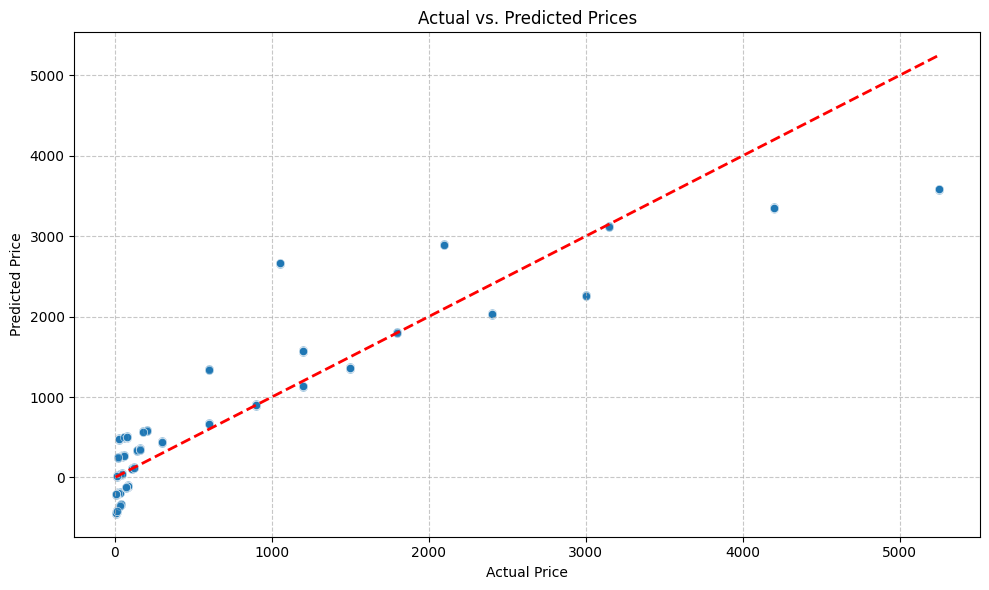

In [ ]:
```python
# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6)
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2) # Line for perfect prediction
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
```

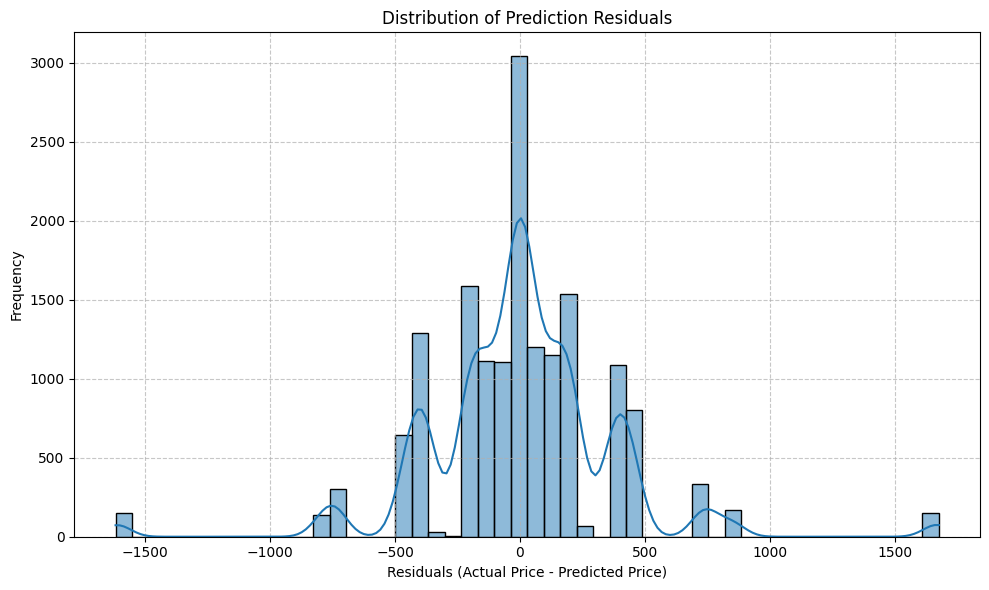

In [ ]:
```python
# Calculate residuals
residuals = y_val - y_pred

# Plot a histogram of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Prediction Residuals')
plt.xlabel('Residuals (Actual Price - Predicted Price)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
```

### Product Price Prediction

In [ ]:
```python
# Create a sample input for prediction. We'll use a row from X_train as a base.
# Let's take the first row of X_train and modify some values for a hypothetical product.
sample_product_features = X_train.iloc[0:1].copy()

# Modify some features for our hypothetical product
sample_product_features['quantity'] = 3
sample_product_features['unit_price'] = 50.0
# Ensure all one-hot encoded category columns are present, setting others to 0
for col in X_train.columns:
    if 'category_' in col and col not in sample_product_features.columns:
        sample_product_features[col] = 0
sample_product_features['category_Clothing'] = 1 # Assume it's a clothing item

# Ensure all one-hot encoded gender columns are present, setting others to 0
for col in X_train.columns:
    if 'gender_' in col and col not in sample_product_features.columns:
        sample_product_features[col] = 0
# If 'gender_Male' or 'gender_Female' are in X_train, they should be set appropriately.
# The problem description indicated 'gender' was one-hot encoded with drop_first=True, so it should be 'gender_Male'.
if 'gender_Male' in sample_product_features.columns:
    sample_product_features['gender_Male'] = 0 # Example: Female customer

# Ensure all one-hot encoded payment_method columns are present, setting others to 0
for col in X_train.columns:
    if 'payment_method_' in col and col not in sample_product_features.columns:
        sample_product_features[col] = 0
sample_product_features['payment_method_Credit Card'] = 1 # Assume Credit Card payment

# Reorder columns to match X_train.columns exactly
sample_product_features = sample_product_features[X_train.columns]

print("Sample Product Features:")
display(sample_product_features)

# Calculate the actual total price for this sample based on quantity and unit_price
actual_total_price = sample_product_features['quantity'].iloc[0] * sample_product_features['unit_price'].iloc[0]

# Make a prediction using the trained model
predicted_price = linear_model.predict(sample_product_features)

print(f"\nCalculated Actual Total Price for the sample: ${actual_total_price:.2f}")
print(f"Predicted Total Price for the sample product: ${predicted_price[0]:.2f}")
print(f"Difference (Actual - Predicted): ${actual_total_price - predicted_price[0]:.2f}")
```

Sample Product Features:


,quantity,unit_price,year,month,day_of_week,day_of_month,avg_category_price_x,total_category_quantity_x,avg_category_price_y,total_category_quantity_y,gender_Male,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys,payment_method_Credit Card,payment_method_Debit Card
32922,3,50.0,2021,4,0,5,107.600439,24078,107.600439,24078,0,1,False,False,False,False,False,True,1,False



Calculated Actual Total Price for the sample: $150.00
Predicted Total Price for the sample product: $108.59
Difference (Actual - Predicted): $41.41


### Predict on Test Data

In [ ]:
```python
# Make a copy to avoid modifying the original test_df_cleaned
test_df_processed = test_df_cleaned.copy()

# 1. Calculate the unit price for each item in the test set
test_df_processed['unit_price'] = test_df_processed['price'] / test_df_processed['quantity']

# 2. Extract time-based features from 'invoice_date' in the test set
test_df_processed['year'] = test_df_processed['invoice_date'].dt.year
test_df_processed['month'] = test_df_processed['invoice_date'].dt.month
test_df_processed['day_of_week'] = test_df_processed['invoice_date'].dt.dayofweek
test_df_processed['day_of_month'] = test_df_processed['invoice_date'].dt.day

# 3. Merge aggregated category features (calculated from training data) into the test set
# Ensure category_agg_features is available from the training preprocessing step
test_df_processed = pd.merge(test_df_processed, category_agg_features, on='category', how='left')

# 4. One-hot encode 'gender', 'category', and 'payment_method' in the test set
test_df_processed = pd.get_dummies(test_df_processed, columns=['gender', 'category', 'payment_method'], drop_first=True)

# Define features (X_test) and target (y_test) for the test set
# Drop original identifier columns, datetime, shopping_mall, age, and price
# Explicitly drop the original 'gender' and 'category' columns
X_test = test_df_processed.drop(columns=[
    'customer_id', 'invoice_date', 'shopping_mall', 'price', 'age',
    'gender', 'category' # Explicitly drop original categorical columns
], errors='ignore')
y_test = test_df_processed['price']

# Align columns with X_train - This is crucial to ensure both datasets have the same features in the same order
# Any columns in X_train not in X_test will be added with 0s
# Any columns in X_test not in X_train will be dropped
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Make predictions on the preprocessed test set
y_pred_test = linear_model.predict(X_test)

# Create a DataFrame for comparison
predictions_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred_test})

# Display the first 10 rows of predicted vs actual prices
print("\nFirst 10 rows of Actual vs. Predicted Prices (Test Set):")
display(predictions_df.head(10))
```

X_test shape: (19892, 20)
y_test shape: (19892,)

First 10 rows of Actual vs. Predicted Prices (Test Set):


,Actual Price,Predicted Price
0,20.92,231.665352
1,26.15,465.331033
2,20.92,227.642021
3,26.15,460.964362
4,2400.68,368.346866
5,179.20,471.915885
6,300.08,-396.544412
7,60.60,229.227243
8,600.16,-161.770954
9,3150.00,243.511661
